In [3]:
!pip install pandas
!pip install sqlalchemy
!pip install pyodbc

In [4]:
import pandas as pd
import sqlalchemy
import pyodbc

print("All packages installed successfully")

All packages installed successfully


In [13]:
import urllib
from sqlalchemy import create_engine

server = "travelins.database.windows.net"
database = "TravelInsuranceDB"
username = "sgsamy"
password = "Srisana@1519"

params = urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 18 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"UID={username};"
    f"PWD={password};"
    f"Encrypt=yes;"
    f"TrustServerCertificate=no;"
)
    
engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}"
)

df = pd.read_sql(
    "SELECT  * FROM dbo.travel_insurance_analytics",
    engine
)

print(df.head())

   Policy_ID Customer_ID  Premium_GBP  Claim_Amount_GBP  Email_Open_Rate  \
0  POL000001  CUST000001       361.50               0.0             5.81   
1  POL000002  CUST000002        39.54               0.0            52.48   
2  POL000003  CUST000003        35.30               0.0            51.42   
3  POL000004  CUST000004       210.97               0.0            44.02   
4  POL000005  CUST000005       185.11               0.0            18.49   

   Renewal_Probability  Churn_Risk_Score  Customer_Lifetime_Value_GBP  \
0                 0.86              0.58                      3569.56   
1                 0.46              0.28                      3098.08   
2                 0.61              0.05                      3076.97   
3                 0.16              0.48                       268.50   
4                 0.96              0.74                      4703.54   

  Churn_Risk_Band      CLV_Band Claim_Status    Renewal_Band  
0          Medium  Medium Value     No Cl

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df.shape

(8000, 12)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Policy_ID                    8000 non-null   object 
 1   Customer_ID                  8000 non-null   object 
 2   Premium_GBP                  8000 non-null   float64
 3   Claim_Amount_GBP             8000 non-null   float64
 4   Email_Open_Rate              8000 non-null   float64
 5   Renewal_Probability          8000 non-null   float64
 6   Churn_Risk_Score             8000 non-null   float64
 7   Customer_Lifetime_Value_GBP  8000 non-null   float64
 8   Churn_Risk_Band              8000 non-null   object 
 9   CLV_Band                     8000 non-null   object 
 10  Claim_Status                 8000 non-null   object 
 11  Renewal_Band                 8000 non-null   object 
dtypes: float64(6), object(6)
memory usage: 750.1+ KB


In [19]:
df.describe()

,Premium_GBP,Claim_Amount_GBP,Email_Open_Rate,Renewal_Probability,Churn_Risk_Score,Customer_Lifetime_Value_GBP
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,234.605040,484.651664,50.260584,0.522311,0.480001,2571.873065
std,124.982341,1528.972080,28.575424,0.273938,0.269900,1408.986400
min,15.050000,0.000000,0.010000,0.050000,0.010000,102.170000
25%,125.622500,0.000000,25.980000,0.290000,0.250000,1355.022500
50%,235.550000,0.000000,50.730000,0.520000,0.480000,2590.405000
75%,342.827500,0.000000,74.477500,0.760000,0.710000,3786.995000
max,449.980000,7979.580000,100.000000,0.990000,0.950000,4999.860000


In [21]:
df.head()

,Policy_ID,Customer_ID,Premium_GBP,Claim_Amount_GBP,Email_Open_Rate,Renewal_Probability,Churn_Risk_Score,Customer_Lifetime_Value_GBP,Churn_Risk_Band,CLV_Band,Claim_Status,Renewal_Band
0,POL000001,CUST000001,361.50,0.0,5.81,0.86,0.58,3569.56,Medium,Medium Value,No Claim,Likely Renew
1,POL000002,CUST000002,39.54,0.0,52.48,0.46,0.28,3098.08,Low,Medium Value,No Claim,Possible Renew
2,POL000003,CUST000003,35.30,0.0,51.42,0.61,0.05,3076.97,Low,Medium Value,No Claim,Possible Renew
3,POL000004,CUST000004,210.97,0.0,44.02,0.16,0.48,268.50,Medium,Low Value,No Claim,At Risk
4,POL000005,CUST000005,185.11,0.0,18.49,0.96,0.74,4703.54,High,High Value,No Claim,Likely Renew


In [23]:
df.groupby('Churn_Risk_Band').agg({
    'Customer_ID':'count',
    'Customer_Lifetime_Value_GBP':'mean',
    'Renewal_Probability':'mean'
})

,Customer_ID,Customer_Lifetime_Value_GBP,Renewal_Probability
Churn_Risk_Band,,,
High,2138,2557.005711,0.523012
Low,3234,2532.253021,0.525702
Medium,2628,2632.724521,0.517568


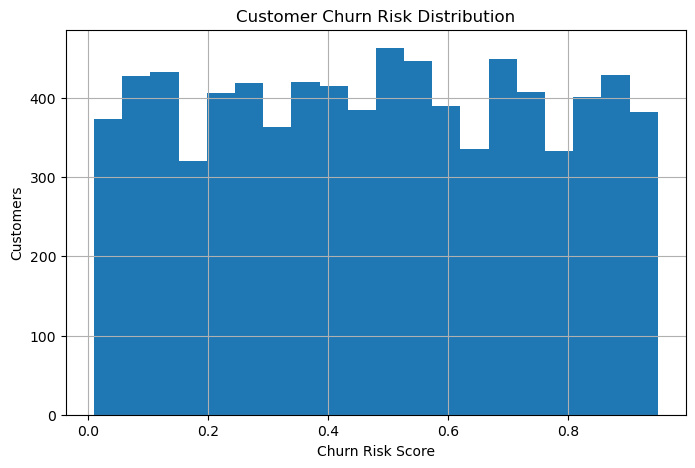

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df['Churn_Risk_Score'].hist(bins=20)
plt.title('Customer Churn Risk Distribution')
plt.xlabel('Churn Risk Score')
plt.ylabel('Customers')
plt.show()

In [27]:
df.shape


(8000, 12)

In [29]:
df.describe()

,Premium_GBP,Claim_Amount_GBP,Email_Open_Rate,Renewal_Probability,Churn_Risk_Score,Customer_Lifetime_Value_GBP
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,234.605040,484.651664,50.260584,0.522311,0.480001,2571.873065
std,124.982341,1528.972080,28.575424,0.273938,0.269900,1408.986400
min,15.050000,0.000000,0.010000,0.050000,0.010000,102.170000
25%,125.622500,0.000000,25.980000,0.290000,0.250000,1355.022500
50%,235.550000,0.000000,50.730000,0.520000,0.480000,2590.405000
75%,342.827500,0.000000,74.477500,0.760000,0.710000,3786.995000
max,449.980000,7979.580000,100.000000,0.990000,0.950000,4999.860000


Customer churn risk is distributed across low, medium, and high-risk customers, indicating that retention strategies should target multiple risk segments rather than focusing on a single customer group.

In [32]:
df.groupby('Churn_Risk_Band').agg(
{
    'Customer_ID':'count',
    'Premium_GBP':'mean',
    'Customer_Lifetime_Value_GBP':'mean',
    'Renewal_Probability':'mean'
}).round(2)

,Customer_ID,Premium_GBP,Customer_Lifetime_Value_GBP,Renewal_Probability
Churn_Risk_Band,,,,
High,2138,233.11,2557.01,0.52
Low,3234,236.17,2532.25,0.53
Medium,2628,233.90,2632.72,0.52


In [34]:
df.groupby('Renewal_Band').agg(
{
    'Customer_ID':'count',
    'Premium_GBP':'mean',
    'Customer_Lifetime_Value_GBP':'mean'
}).round(2)

,Customer_ID,Premium_GBP,Customer_Lifetime_Value_GBP
Renewal_Band,,,
At Risk,2938,234.43,2545.97
Likely Renew,2549,232.65,2598.33
Possible Renew,2513,236.80,2575.32


In [36]:
df.groupby('CLV_Band').agg(
{
    'Customer_ID':'count',
    'Premium_GBP':'mean',
    'Claim_Amount_GBP':'mean'
}).round(2)

,Customer_ID,Premium_GBP,Claim_Amount_GBP
CLV_Band,,,
High Value,1639,238.14,509.56
Low Value,3058,234.71,493.09
Medium Value,3303,232.76,464.48


In [38]:
corr = df[
[
'Premium_GBP',
'Claim_Amount_GBP',
'Email_Open_Rate',
'Renewal_Probability',
'Churn_Risk_Score',
'Customer_Lifetime_Value_GBP'
]
].corr()

corr

,Premium_GBP,Claim_Amount_GBP,Email_Open_Rate,Renewal_Probability,Churn_Risk_Score,Customer_Lifetime_Value_GBP
Premium_GBP,1.000000,0.002049,0.012359,-0.007754,-0.010498,0.002044
Claim_Amount_GBP,0.002049,1.000000,-0.004370,0.000084,-0.012004,-0.002767
Email_Open_Rate,0.012359,-0.004370,1.000000,-0.002668,0.003942,-0.006811
Renewal_Probability,-0.007754,0.000084,-0.002668,1.000000,-0.006916,0.018885
Churn_Risk_Score,-0.010498,-0.012004,0.003942,-0.006916,1.000000,0.008173
Customer_Lifetime_Value_GBP,0.002044,-0.002767,-0.006811,0.018885,0.008173,1.000000


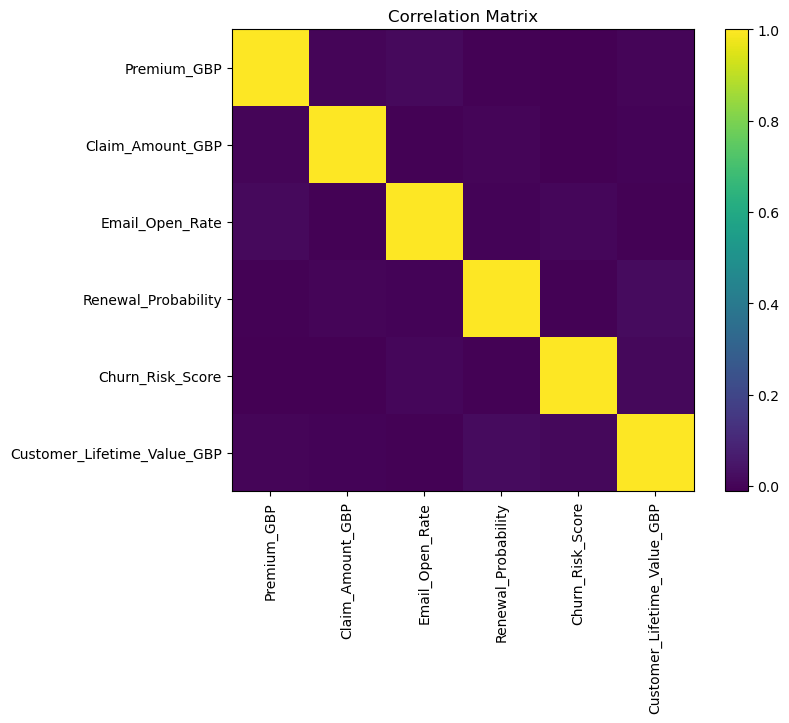

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
plt.show()

In [42]:
df['Renewal_Band'].value_counts()

Renewal_Band
At Risk           2938
Likely Renew      2549
Possible Renew    2513
Name: count, dtype: int64

In [44]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Renewal_Target'] = le.fit_transform(
    df['Renewal_Band']
)

In [46]:
X = df[
[
'Premium_GBP',
'Claim_Amount_GBP',
'Email_Open_Rate',
'Churn_Risk_Score',
'Customer_Lifetime_Value_GBP'
]
]

y = df['Renewal_Target']

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print(
    accuracy_score(y_test,pred)
)

0.330625


In [50]:
df = pd.read_sql(
    "SELECT * FROM dbo.travel_insurance_analytics",
    engine
)

In [52]:
import numpy as np

np.random.seed(42)

products = [
    "Single Trip",
    "Annual Multi Trip",
    "Cruise",
    "Winter Sports",
    "Backpacker"
]

regions = [
    "Europe",
    "Asia",
    "North America",
    "Middle East",
    "Oceania"
]

destinations = [
    "Spain",
    "France",
    "Italy",
    "USA",
    "Thailand",
    "Australia",
    "Turkey",
    "Japan"
]

cover_levels = [
    "Basic",
    "Standard",
    "Premium"
]

segments = [
    "Bronze",
    "Silver",
    "Gold",
    "Platinum"
]

channels = [
    "Website",
    "Aggregator",
    "Call Centre",
    "Email Campaign"
]

actions = [
    "Retain",
    "Upsell",
    "Cross-Sell",
    "Reactivate",
    "No Action"
]

df["Product"] = np.random.choice(products, len(df))
df["Region"] = np.random.choice(regions, len(df))
df["Destination"] = np.random.choice(destinations, len(df))
df["Cover_Level"] = np.random.choice(cover_levels, len(df))
df["Customer_Segment"] = np.random.choice(segments, len(df))
df["Sales_Channel"] = np.random.choice(channels, len(df))
df["Next_Best_Action"] = np.random.choice(actions, len(df))

High CLV Customers

In [54]:
df.loc[
    df["Customer_Lifetime_Value_GBP"] > 4000,
    "Customer_Segment"
] = "Platinum"

Medium CLV

In [58]:
df.loc[
    (df["Customer_Lifetime_Value_GBP"] >= 2500)
    &
    (df["Customer_Lifetime_Value_GBP"] <= 4000),
    "Customer_Segment"
] = "Gold"

High Churn Risk

In [61]:
df.loc[
    df["Churn_Risk_Score"] > 0.70,
    "Next_Best_Action"
] = "Retain"

High Renewal Probability

In [64]:
df.loc[
    df["Renewal_Probability"] > 0.80,
    "Next_Best_Action"
] = "Upsell"

Write Back to Azure SQL

In [67]:
df.to_sql(
    "travel_insurance_enriched",
    engine,
    if_exists="replace",
    index=False
)

80

In [71]:
engine.dispose()

In [73]:
import urllib
import pandas as pd
from sqlalchemy import create_engine

server = "travelins.database.windows.net"
database = "TravelInsuranceDB"
username = "sgsamy"
password = "Srisana@1519"

params = urllib.parse.quote_plus(
    f"DRIVER={{ODBC Driver 18 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"UID={username};"
    f"PWD={password};"
    f"Encrypt=yes;"
    f"TrustServerCertificate=no;"
)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}"
)

In [75]:
df = pd.read_sql(
    "SELECT * FROM dbo.travel_insurance_enriched",
    engine
)

df.shape

(8000, 19)

In [77]:
import numpy as np

np.random.seed(42)

years = np.random.choice(
    [2022, 2023, 2024, 2025],
    len(df),
    p=[0.15, 0.20, 0.30, 0.35]
)

months = np.random.randint(1, 13, len(df))
days = np.random.randint(1, 28, len(df))

df["Policy_Sale_Date"] = pd.to_datetime({
    "year": years,
    "month": months,
    "day": days
})

df[["Policy_ID", "Policy_Sale_Date"]].head()

,Policy_ID,Policy_Sale_Date
0,POL000001,2024-02-04
1,POL000002,2025-10-02
2,POL000003,2025-11-09
3,POL000004,2024-01-18
4,POL000005,2023-10-17


In [79]:
df.to_sql(
    "travel_insurance_enriched",
    engine,
    if_exists="replace",
    index=False
)

96